-----------------------------
# Loading our libraries:
-----------------------------

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

-----------------------------
## Dataset: 
-----------------------------
The dataset comprises a follow-up sample of 1937 beneficiaries who received monthly cash assistance aimed at improving the quality and quantity of food they consumed, as measured by the Food Consumption Scores (FCS), over a duration of 2 years. To assess the impact of the cash assistance, a control group consisting of 1640 individuals from the same community, sharing similar socio-economic backgrounds, was selected. The 1937 beneficiaries constituted the intervention group, while the 1640 individuals formed the control group.

Data regarding the FCS status was collected before the commencement of the assistance program for both the intervention and control groups, and it was recorded in the dataset as 'FCS at Baseline'. Subsequently, upon completion of the 2-year project, data on the FCS status was again gathered from both groups and recorded in the dataset as 'FCS at endline'. By employing the Difference in Difference technique, we aim to comprehensively and reliably evaluate the impact of the cash assistance on the quality and quantity of food consumed by the beneficiaries, as measured by the FCS.

In [2]:
# importing the dataset

data = pd.read_csv("Evaluation of FCS.csv")

In [3]:
# exploring the first 5 rows of the dataset

data.head()

,Project Status,FCS at Baseline,FCS at Endline
0,Beneficiaries,50,54
1,Beneficiaries,55,50
2,Beneficiaries,50,53
3,Beneficiaries,52,54
4,Beneficiaries,53,51


In [4]:
# changing Project Beneficiary values into an integer: changing Beneficiaries to 1 and Non beneficiaries to 0

data["Project Status"] = data["Project Status"].map({'Beneficiaries': 1, 'Non beneficiaries': 0})

# Exploring the dataset

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3577 entries, 0 to 3576
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Project Status   3577 non-null   int64
 1   FCS at Baseline  3577 non-null   int64
 2   FCS at Endline   3577 non-null   int64
dtypes: int64(3)
memory usage: 84.0 KB


In [6]:
# exploring the first 5 rows of the dataset

data.head()

,Project Status,FCS at Baseline,FCS at Endline
0,1,50,54
1,1,55,50
2,1,50,53
3,1,52,54
4,1,53,51


In [7]:
# Summary statistics of baseline and endline values by project status

data.groupby("Project Status")[["FCS at Baseline", "FCS at Endline"]].describe()

FCS at Baseline                                               \
                         count       mean       std   min   25%   50%   75%   
Project Status                                                                
0                       1640.0  54.224390  2.865441  50.0  52.0  54.0  56.0   
1                       1937.0  53.409912  2.533916  50.0  52.0  53.0  55.0   

                     FCS at Endline                                         \
                 max          count       mean       std   min   25%   50%   
Project Status                                                               
0               69.0         1640.0  54.521951  2.989631  50.0  52.0  54.0   
1               65.0         1937.0  54.324729  2.913947  50.0  52.0  54.0   

                            
                 75%   max  
Project Status              
0               56.0  68.0  
1               56.0  65.0

# Creating the difference in difference function

In [8]:
def diff_in_diff(endline_variable, baseline_variable, project_status):
    table = pd.DataFrame({
        'Baseline': baseline_variable,
        'Endline': endline_variable,
        'Project Beneficiary': project_status
    })

    # Calculate the mean values by project status
    table = table.groupby(table['Project Beneficiary']).mean()

    # Calculate the difference between column 2 and column 1
    table['Impact without Diff-in-Diff'] = table.iloc[:, 1] - table.iloc[:, 0]

    # Round the values to one decimal point
    table = table.round(1)

    control_bas = table.loc[0, 'Baseline']
    control_eval = table.loc[0, 'Endline']
    intervention_bas = table.loc[1, 'Baseline']
    intervention_eval = table.loc[1, 'Endline']

    control_diff = control_eval - control_bas
    intervention_diff = intervention_eval - intervention_bas
    did = intervention_diff - control_diff

    print(f'Results at baseline for the intervention group: {intervention_bas:.1f}')
    print(f'Results at endline for the intervention group: {intervention_eval:.1f}')
    print(f'Results at baseline for the control group: {control_bas:.1f}')
    print(f'Results at endline for the control group: {control_eval:.1f}')
    print(f'DID in Results is {did:.1f}')

    # Print the table
    print(table)

    # X-axis values (baseline and endline)
    x = ['Baseline', 'Endline']

    # Y-axis values for the intervention group
    intervention_y = [intervention_bas, intervention_eval]

    # Y-axis values for the control group
    control_y = [control_bas, control_eval]

    # Calculate evaluation value for the dotted line
    dotted_eval = control_eval + (intervention_bas - control_bas)

    # Calculate the impact
    impact = intervention_eval - dotted_eval

    # Plotting the lines
    plt.plot(x, intervention_y, 'g', label='Intervention Group')
    plt.plot(x, control_y, 'r', label='Control Group')
    plt.plot(x, [intervention_bas, dotted_eval], 'g--', label='Intervention Group without the Project')

    # Determine the color for shading based on evaluation values
    if intervention_eval > dotted_eval:
        color = 'lightgreen'
    else:
        color = 'lightcoral'

    # Fill the area between the lines with the specified color
    plt.fill_between(x, intervention_y, [intervention_bas, dotted_eval], color=color)

    # Adding labels and title
    plt.xlabel('Time')
    plt.ylabel('Results')
    plt.title('Diff in Diff of Intervention vs Control Groups')

    # Moving the legend outside and positioning it on the right side
    plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))

   
    # Annotating the impact value
    plt.text(x[1], dotted_eval, f'Impact = {impact:.1f}', ha='right', va='bottom')

    # Displaying the plot
    plt.show()

# Presenting the results

Results at baseline for the intervention group: 53.4
Results at endline for the intervention group: 54.3
Results at baseline for the control group: 54.2
Results at endline for the control group: 54.5
DID in Results is 0.6
                     Baseline  Endline  Impact without Diff-in-Diff
Project Beneficiary                                                
0                        54.2     54.5                          0.3
1                        53.4     54.3                          0.9


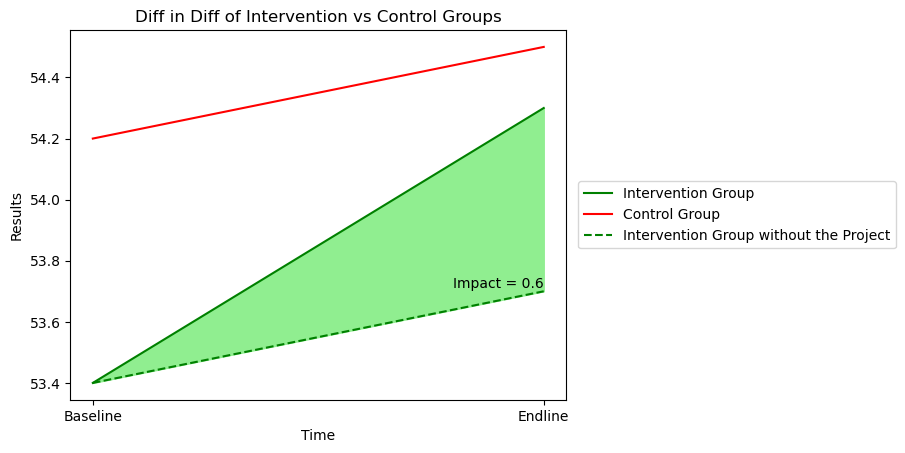

In [9]:
diff_in_diff(data['FCS at Endline'], data['FCS at Baseline'], data['Project Status'])

# Conclusion

The Food Consumption Scores (FCS) exhibited an improvement of 0.9 units among the beneficiaries between the baseline and endline assessments, while the non-beneficiaries experienced an increase of 0.3 units. This suggests that, even in the absence of the treatment (cash assistance), the FCS for the beneficiaries could still have demonstrated an improvement of 0.3 units, resulting in a potential FCS value of 53.7 at the endline. 

Consequently, the actual impact of the cash assistance on the FCS of the beneficiaries at the endline is determined by subtracting the projected FCS without the cash assistance (53.7) from the observed FCS with the assistance at the endline (54.3). The difference, amounting to 0.6 units, was the actual impact of the cash assistance on the beneficiaries' FCS.